### 黃丞暘 611211106

### (1)
給定
$$
F^{-1}(y)=\text{inf}\ \{x \mid F(x) \ge y \} 
$$

由反函數定義
$$
F^{-1}(U)\le x \Leftrightarrow U \le F(x)
$$

而且因為 $U \sim U(0, 1)$，所以
$$
P(U \le F(x)) = F(x)
$$

結合以上，可以得到
$$
P(F^{-1}(U)\le x)=P(U \le F(x)) =F(x)
$$

表示 $F^{-1}(U)$ 的 c.d.f. 就是 $F$，也就是
$$
F^{-1}(U) \sim X
$$

### (2)(a)(i) Rejection sampling

In [ ]:
import numpy as np
from scipy.stats import norm

np.random.seed(42) # 以防後面計算E(X^4)的結果不同

f = lambda x: norm.pdf(x) # 定義target f

# 定義 proposal g
a = -5
b = 5
density = 1/(b-a)
proposal_g = lambda n: np.random.uniform(a, b, n)

# 找到1個常數c使得g可以包住f
c = f(0) / density # c*g(x) <= f(x) -> c <= f(x)/g(x) 

N = 5000
samples = []
while len(samples) < N:
    x = proposal_g(1)[0] 
    # x會是一筆一維陣列array([x]), 後面的[0]是取出當中的x作為純量
    # 可以寫成 x_arrary = proposal_g(1) ; x = x_arrary[0]
    u = np.random.uniform()
    if u <= f(x) / (c*density):
        samples.append(x)

### (2)(a)(ii) Sample importance resampling


In [ ]:
import numpy as np
from scipy.stats import norm

np.random.seed(42) # 以防後面計算E(X^4)的結果不同

f = lambda x: norm.pdf(x) # 定義target f

# 定義 proposal g
a = -5
b = 5
density = 1/(b-a)
proposal_g = lambda x: np.full_like(x, density)

N = 5000
x_samples = np.random.uniform(a, b, N)

w = f(x_samples) / proposal_g(x_samples)
w_sclaed = w / np.sum(w)


resampled = np.random.choice(x_samples, size=N, replace=True, p=w_sclaed)

### (2)(b)(i) Rejection sampling

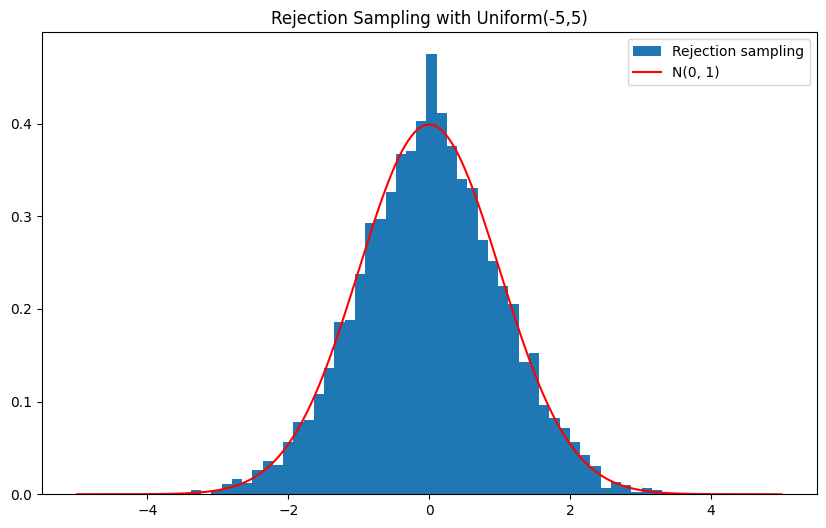

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=50, density=True, label='Rejection sampling')
x = np.linspace(a, b, 500)
plt.plot(x, norm.pdf(x), label='N(0, 1)', color='r')
plt.title("Rejection Sampling with Uniform(-5,5)")
plt.legend()
plt.show()

### (2)(b)(ii) Sample importance resampling

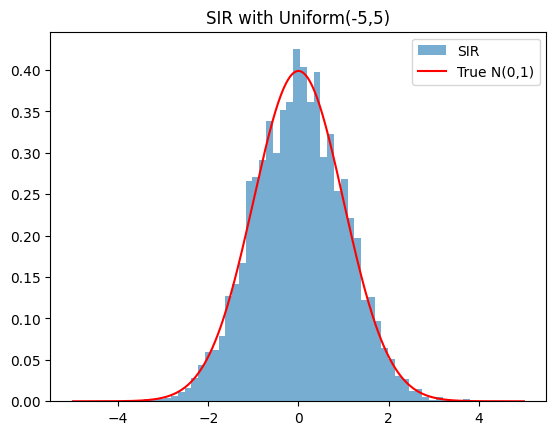

In [8]:
import matplotlib.pyplot as plt
x_plot = np.linspace(-5, 5, 500)
plt.hist(resampled, bins=50, density=True, alpha=0.6, label="SIR")
plt.plot(x_plot, norm.pdf(x_plot), color='r', label="True N(0,1)")
plt.title("SIR with Uniform(-5,5)")
plt.legend()
plt.show()

### (2)(c)(i) Rejection sampling 

In [4]:
samples = np.array(samples)
E_X4 = np.mean(samples**4)
print(f"Estimated E[X^4] = {E_X4:.4f}")

Estimated E[X^4] = 3.1466


### (2)(c)(ii) Sampling Importance resampling 

In [11]:
resamples = np.array(resampled)
E_X4 = np.mean(resamples**4)
print(f"Estimated E[X^4] = {E_X4:.4f}")

Estimated E[X^4] = 2.9521


### (3)(a)

In [17]:
import numpy as np
from scipy.stats import binom

# 設定 n, p 配合(3)(b)
n = 3
p = 0.6
range_= np.arange(0, n+1)

np.random.seed(42) # 以防後面計算E(X^3+X^2)的結果不同

f = binom.pmf(range_, n, p) # 定義target f

# 定義 proposal g
g = np.full_like(f, 1/(n+1))

# 找到1個常數c使得g可以包住f
c = np.max(f/g) # c*g(x) <= f(x) -> c <= f(x)/g(x) 

N = 5000
samples = []
while len(samples) < N:
    x = np.random.randint(0, n+1)  # 從 Uniform(0,...,n) 抽樣
    u = np.random.uniform()
    accept_p = binom.pmf(x, n, p) / (c * (1/(n+1)))
    if u <= accept_p:
        samples.append(x)

### (3)(b)

In [20]:
samples = np.array(samples)
E_X3 = np.mean(samples**3)
E_X2 = np.mean(samples**2)
print(f"Estimated E[X^4+E^3] = {(E_X3+E_X2):.4f}")

Estimated E[X^4+E^3] = 13.7056


### (3)(c)
已知
$$
X \sim Bin(n=3, p=0.6)
$$

所以
$$
f_X(x) = \dbinom{3}{x}(0.6)^x(0.4)^{3-x}
$$

可計算
$$
E(X^3+X^2)=E(X^3)+E(X^2)=\sum^3_{x=0}x^3f(x)+\sum^3_{x=0}x^2f(x)=13.536
$$

與 (b) 比較，誤差值約
$ e = (b)/(c)=13.7056/13.536\approx1.01\%$